# sgf vs cutde

This notebook compares surface-displacement Green's functions computed with `sgf` and `cutde` for three small fault patches with different orientations.

`cutde` provides the half-space reference solution, while `sgf` computes the same response numerically with Tandem.

Run `sgf` first:

```bash
gmsh -3 sgf_3_faults_example.geo -o sgf_3_faults_example.msh
mpirun -n 8 ./sgf sgf_3_faults_example.toml --petsc \
    -ksp_type cg -pc_type gamg -ksp_rtol 1e-10 -ksp_converged_reason
```

Python packages used below: `numpy`, `scipy`, `xarray`, `h5netcdf`, `h5py`, `matplotlib`, `pandas`, and `cutde`.


## Setup

This cell defines the information needed to make the `cutde` calculation match the `sgf` calculation.

### Fault geometry

`cutde` needs the vertices of each fault triangle. `sgf` reads this geometry from the Gmsh mesh but does not store the original triangle definitions in the Green's-function output, so the same fault geometry is defined here.

If the fault geometry in `sgf_3_faults_example.geo` changes, it must also be changed here.

### Slip directions

The two codes use their own local fault coordinate systems. Rather than assuming that their labels for positive dip and strike point in the same direction, we compare the **same Cartesian slip vector** in both codes.

`ref_normal` determines which side of each fault is treated as up and which as down, keeping the fault orientation consistent across all facets. With the normal oriented, the fault basis is

$$
\mathbf{s} = \mathbf{up} \times \mathbf{n},
\qquad
\mathbf{d} = \mathbf{s} \times \mathbf{n}.
$$

Slip direction 0 is dip ($\mathbf{d}$), and slip direction 1 is strike ($\mathbf{s}$).

The code below expresses these same Cartesian directions in the local coordinate system expected by `cutde`.

`up`, `ref_normal`, and the observation points are read directly from the TOML file.


In [9]:
import tomllib
import numpy as np

with open("sgf_3_faults_example.toml", "rb") as f:
    cfg = tomllib.load(f)

UP = np.array(cfg["up"])
REF_NORMAL = np.array(cfg["ref_normal"])
NU = 0.25                                  # lam = mu in the lua file

NAMES = [p["name"] for p in cfg["receiver_probe_output"]["probes"]]
OBS = np.array([p["x"] for p in cfg["receiver_probe_output"]["probes"]])
TAGS = [101, 102, 103]                     # Physical Surface tags in the geo
LABEL = ["ux", "uy", "uz"]

# Fault triangle vertices. These must match sgf_3_faults_example.geo.
TRIS = np.array([
    [[-3.577350, -4.000000, -2.666667], [-3.577350, -2.000000, -2.666667], [-1.845299, -3.000000, -3.666667]],
    [[1.898272, -2.091752, -3.028595], [3.630323, -1.091752, -3.028595], [3.471405, -2.816497, -4.442809]],
    [[-0.699359, 3.788675, -2.422650], [1.032692, 2.788675, -2.422650], [-0.333333, 2.422650, -4.154701]]
])


def unit(v):
    return np.asarray(v) / np.linalg.norm(v)


def sgf_frame(tri):
    """(normal, dip direction, strike direction) as sgf builds them."""
    n = unit(np.cross(tri[1] - tri[0], tri[2] - tri[0]))
    if n @ REF_NORMAL < 0.0:
        n = -n
    s = unit(np.cross(UP, n))
    return n, unit(np.cross(s, n)), s


def cutde_frame(tri):
    """(normal, strike, dip) as cutde defines them."""
    n = unit(np.cross(tri[1] - tri[0], tri[2] - tri[0]))
    vs = np.cross(UP, n)
    vs = unit(vs) if np.linalg.norm(vs) > 1e-12 else np.array([0.0, 1.0, 0.0]) * n[2]
    return n, vs, np.cross(n, vs)


# Cartesian slip vector sgf applies, per (fault, direction).
SLIP = np.zeros((len(TAGS), 2, 3))
print(" tag    dip  strike_az   normal")
for k, tri in enumerate(TRIS):
    n, d, s = sgf_frame(tri)
    SLIP[k, 0], SLIP[k, 1] = d, s
    print(f"{TAGS[k]:4d} {np.degrees(np.arccos(abs(n[2]))):6.2f} "
          f"{np.degrees(np.arctan2(s[0], s[1])) % 360.0:10.2f}   {np.round(n, 3)}")


 tag    dip  strike_az   normal
 101  30.00       0.00   [ 0.5   -0.     0.866]
 102  45.00      60.00   [ 0.354 -0.612  0.707]
 103  60.00     120.00   [-0.433 -0.75   0.5  ]


## cutde reference solution

`cutde.halfspace.disp_matrix` computes the displacement Green's functions for triangular dislocations in an elastic half-space.

Here we evaluate the `cutde` solution on the same surface grid and at the same observation points used by `sgf`.


In [ ]:
import xarray as xr
import cutde.halfspace as HS

ds = xr.open_dataset("sgf_3_faults_example_grid.h5", engine="h5netcdf")
gx, gy = ds.x.values, ds.y.values
extent = [gx[0], gx[-1], gy[0], gy[-1]]
print(f"grid {len(gx)} x {len(gy)}, spacing {gx[1] - gx[0]:.4f} km")


def cutde_disp(points):
    """cutde displacement for the slip sgf applies, shape (tag, direction, pt, 3)."""
    M = HS.disp_matrix(np.asarray(points, np.float64), TRIS.astype(np.float64), NU)
    out = np.zeros((len(TAGS), 2, len(points), 3))
    for k, tri in enumerate(TRIS):
        n_c, vs_c, vd_c = cutde_frame(tri)
        for direction in range(2):
            v = SLIP[k, direction]
            out[k, direction] = M[:, :, k, :] @ np.array([v @ vs_c, v @ vd_c, v @ n_c])
    return out


XX, YY = np.meshgrid(gx, gy)
cutde_grid = xr.DataArray(
    cutde_disp(np.column_stack([XX.ravel(), YY.ravel(), np.zeros(XX.size)]))
        .reshape(len(TAGS), 2, len(gy), len(gx), 3),
    name="cutde", dims=("tag", "direction", "y", "x", "component"),
    coords=dict(tag=TAGS, direction=[0, 1], y=gy, x=gx, component=[0, 1, 2]))

cutde_obs = xr.DataArray(
    cutde_disp(OBS), name="cutde",
    dims=("tag", "direction", "obs", "component"),
    coords=dict(tag=TAGS, direction=[0, 1], obs=NAMES, component=[0, 1, 2]))

print("max |u| on grid:", float(abs(cutde_grid).max()))


## Surface displacement maps

Choose the source-slip direction with `DIRECTION`:

- `0` = dip slip
- `1` = strike slip

Choose the displacement component with `COMPONENT`:

- `0` = x
- `1` = y
- `2` = z

For each fault, the plots show the `sgf` result, the `cutde` result, and their difference.

The difference map helps identify where the numerical solutions disagree. Differences near fault edges are commonly associated with mesh discretization, while differences that increase toward the model boundaries can reflect the finite size of the Tandem domain compared with the infinite half-space used by `cutde`.


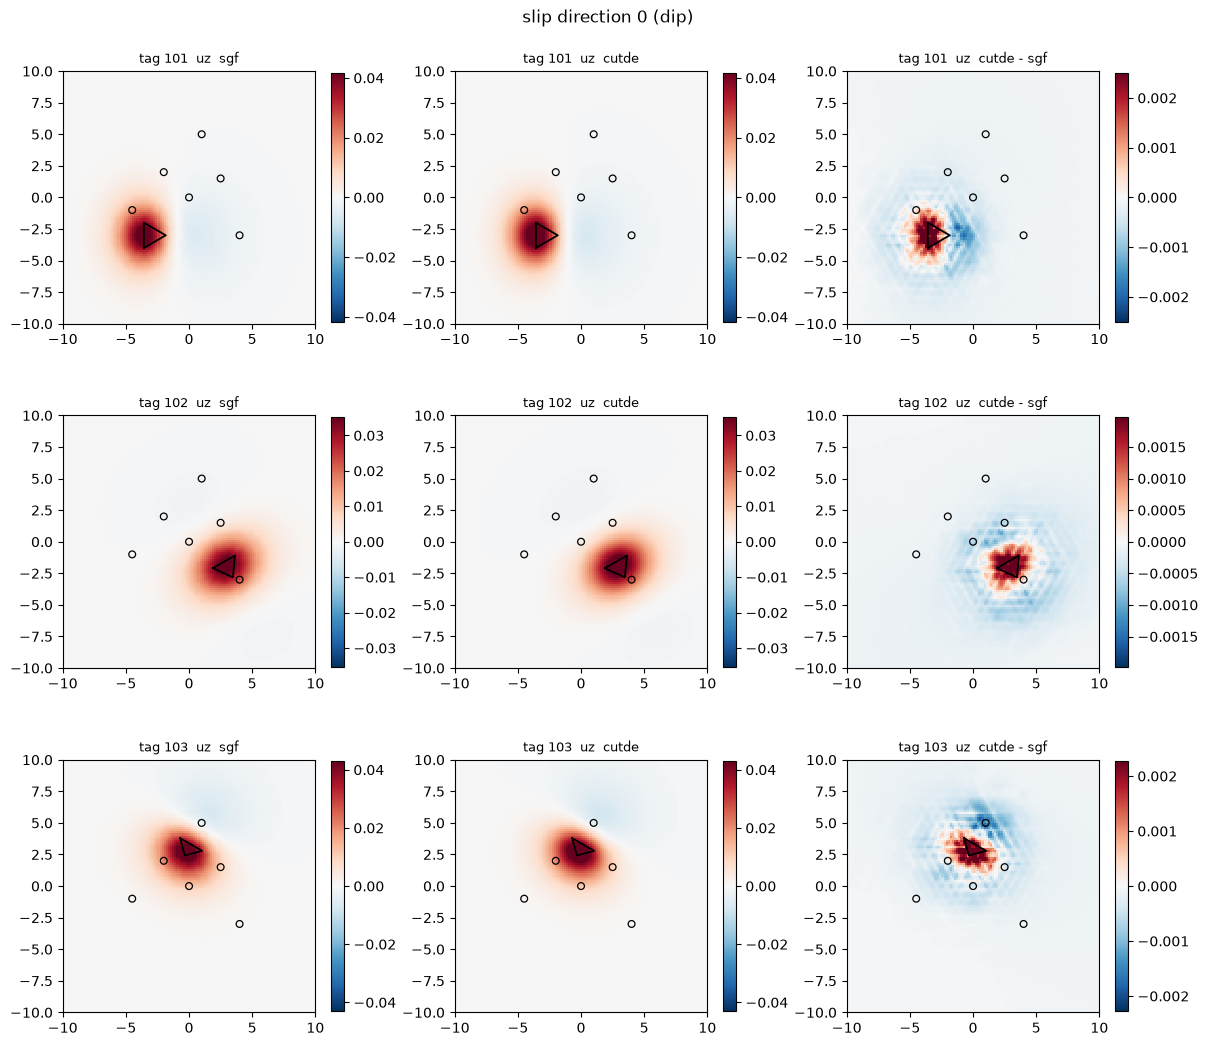

In [10]:
import matplotlib.pyplot as plt

DIRECTION = 0    # 0 = dip, 1 = strike
COMPONENT = 2    # 0 = ux, 1 = uy, 2 = uz

sgf_grid = (xr.concat([ds[str(tag)] for tag in TAGS], dim="tag")
              .assign_coords(tag=TAGS)
              .transpose("tag", "direction", "y", "x", "component"))

# Overall sign depends on which side of the fault the jump is measured from.
sign = np.sign(float((cutde_grid * sgf_grid).sum() / (sgf_grid ** 2).sum()))
if sign < 0:
    print("sign flipped: use the opposite ref_normal")
sgf_grid = sign * sgf_grid

fig, axes = plt.subplots(len(TAGS), 3, figsize=(12, 3.6 * len(TAGS)))
for k, tag in enumerate(TAGS):
    a = sgf_grid.sel(tag=tag).isel(direction=DIRECTION, component=COMPONENT).values
    b = cutde_grid.sel(tag=tag).isel(direction=DIRECTION, component=COMPONENT).values
    lim = np.percentile(np.abs(b), 99.5)
    dlim = np.percentile(np.abs(b - a), 99.5)

    for j, (img, title, vlim) in enumerate([(a, "sgf", lim), (b, "cutde", lim),
                                            (b - a, "cutde - sgf", dlim)]):
        ax = axes[k, j]
        im = ax.imshow(img, extent=extent, origin="lower", cmap="RdBu_r",
                       vmin=-vlim, vmax=vlim, interpolation="nearest")
        ax.scatter(OBS[:, 0], OBS[:, 1], s=24, facecolors="none",
                   edgecolors="k", linewidths=0.9)
        tri = TRIS[k]
        ax.plot(np.append(tri[:, 0], tri[0, 0]),
                np.append(tri[:, 1], tri[0, 1]), "k-", lw=1.3)
        ax.set_title(f"tag {tag}  {LABEL[COMPONENT]}  {title}", fontsize=9)
        ax.set_aspect("equal")
        fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(f"slip direction {DIRECTION} "
             f"({'dip' if DIRECTION == 0 else 'strike'})", fontsize=12)
fig.tight_layout()


## Observation points

The HDF5 `probeData` array has shape

`(probe, gf, component)`.

Probes are not necessarily written in the same order as they appear in the TOML file. The code therefore matches each probe using its stored name before comparing `sgf` and `cutde`.


In [ ]:
import h5py
import pandas as pd

with h5py.File("sgf_3_faults_example_probes.h5", "r") as h5:
    data = h5["probeData"][:]
    names = [s.decode().strip() for s in h5["probeNames"][:]]

# gf index runs tag-major, direction-minor, matching the sgf loop.
sgf_obs = xr.DataArray(
    data[[names.index(n) for n in NAMES]]
        .reshape(len(NAMES), len(TAGS), 2, 3).transpose(1, 2, 0, 3) * sign,
    name="sgf", dims=cutde_obs.dims, coords=cutde_obs.coords)

over = ("obs", "component")
print(xr.Dataset(dict(
    max_cutde=abs(cutde_obs).max(over),
    rel_L2=((cutde_obs - sgf_obs) ** 2).sum(over) ** 0.5
           / (cutde_obs ** 2).sum(over) ** 0.5,
    max_rel=abs(cutde_obs - sgf_obs).max(over) / abs(cutde_obs).max(over),
)).assign_coords(direction=["dip", "strike"]).to_dataframe())

rows = [dict(tag=tag, obs=name, comp=LABEL[c],
             cutde=float(cutde_obs.sel(tag=tag, direction=DIRECTION, obs=name,
                                       component=c)),
             sgf=float(sgf_obs.sel(tag=tag, direction=DIRECTION, obs=name,
                                   component=c)))
        for tag in TAGS for name in NAMES for c in range(3)]
table = pd.DataFrame(rows)
table["diff"] = table.sgf - table.cutde
pd.set_option("display.float_format", lambda v: f"{v:+.4e}")
display(table.set_index(["tag", "obs", "comp"]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(cutde_grid.values.ravel(), sgf_grid.values.ravel(), ".", ms=2,
        alpha=0.3, label="grid")
ax.plot(cutde_obs.values.ravel(), sgf_obs.values.ravel(), "o", ms=6,
        label="observation points")
lim = float(abs(cutde_grid).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "k-", lw=0.8)
ax.set(xlabel="cutde", ylabel="sgf", xlim=(-lim, lim), ylim=(-lim, lim))
ax.set_aspect("equal")
ax.legend()
fig.tight_layout()


## Fault orientation output

The optional `[fault_output]` VTU files record the fault coordinate system actually used by `sgf`.

They contain:

- the fault tag,
- the oriented unit normal,
- the dip direction,
- the strike direction,
- both unit-slip direction vectors.

This provides a direct check that the source directions used by `sgf` have the expected orientation.

In the plot:

- blue = direction 0 (dip)
- orange = direction 1 (strike)
- grey = oriented fault normal

For each planar fault patch, arrows of the same type should point in the same direction.


In [ ]:
import glob
import pyvista as pv

pv.set_jupyter_backend("static")

files = (sorted(glob.glob("sgf_3_faults_example_faults*.pvtu"))
         or sorted(glob.glob("sgf_3_faults_example_faults_*.vtu")))
mesh = pv.read(files[0])
for f in files[1:]:
    mesh = mesh.merge(pv.read(f))

for name, cols in [("dip_dir", ("dip_dir_x", "dip_dir_y", "dip_dir_z")),
                   ("strike_dir", ("strike_dir_x", "strike_dir_y", "strike_dir_z")),
                   ("normal", ("nx", "ny", "nz"))]:
    mesh[name] = np.column_stack([mesh[c] for c in cols])

# What sgf wrote, against what the setup cell computed.
print(" tag     dip   strike_az        (sgf output)")
for tag in np.unique(mesh["tag"]).astype(int):
    m = mesh["tag"] == tag
    print(f"{tag:4d} {mesh['dip'][m].mean():7.2f} {mesh['strike'][m].mean():11.2f}")

pl = pv.Plotter(window_size=(900, 650))
pl.add_mesh(mesh, scalars="tag", cmap="tab10", show_edges=True, edge_color="grey",
            line_width=0.4, opacity=0.6, scalar_bar_args=dict(title="gfTag"))
for name, color in [("dip_dir", "tab:blue"), ("strike_dir", "tab:orange"),
                    ("normal", "lightgrey")]:
    pl.add_mesh(mesh.glyph(orient=name, scale=False, factor=0.6,
                           geom=pv.Arrow(tip_length=0.3, tip_radius=0.09,
                                         shaft_radius=0.03),
                           tolerance=0.02),
                color=color, label=name)
pl.add_points(OBS, color="black", point_size=9, render_points_as_spheres=True)
pl.add_legend(bbox=(0.02, 0.76, 0.28, 0.22))
pl.add_axes()
pl.show_grid()
pl.camera_position = "xz"
pl.camera.azimuth = 35
pl.camera.elevation = 22
pl.show()